# Customer LTV & Contribution Analysis: Technical Walkthrough

Full analysis pipeline for a synthetic BNPL fintech: data contracts and a governed metric layer over the raw tables, SQL-based cohort retention and revenue curves, a log-share decomposition of GMV growth into customer/frequency/order-value drivers, acquisition channel quality and mix-shift analysis, a SQL window-function read on growth trend and revenue concentration, a probabilistic BG/NBD + Gamma-Gamma customer lifetime value model validated on a calibration/holdout split, and an early-life gradient boosting model that predicts 12-month GMV from a customer's first 30 days.

For the short, stakeholder-facing version of this project see the [project README](../README.md).

All data here is synthetic, generated by `src/generate_data.py`. No proprietary data, models, or results from any employer are used or implied. This is the same fictional company as project 01, viewed from the growth/LTV side instead of the credit-risk side.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from db import get_connection, run_sql_file
from style import set_style, style_ax, savefig, add_footnote, SLATE, MUTED_TEAL, MUTED_AMBER, MUTED_RED, GREY, PALETTE

set_style()
pd.set_option("display.max_columns", 50)
%matplotlib inline

## 1. Data

15,000 synthetic customers acquired over a 24-month window across four acquisition channels (organic, referral, partner store, paid social), each generating order-level transactions. Purchase timing and dropout follow a BG/NBD-consistent process (heterogeneous Poisson purchase rate, per-transaction dropout probability), and order value follows a Gamma-Gamma-consistent process (customer-level average value with per-order noise). Channel mix shifts over time: early cohorts skew organic/referral, later cohorts skew paid social, as the company scales up paid acquisition.

In [2]:
con = get_connection()
customers = con.execute("SELECT * FROM customers").fetchdf()
orders = con.execute("SELECT * FROM orders").fetchdf()
print(f"{len(customers):,} customers, {len(orders):,} orders")
print(f"Orders per customer: mean={orders.groupby('customer_id').size().mean():.2f}")
customers.head()

15,000 customers, 94,358 orders
Orders per customer: mean=6.29


,customer_id,cohort_month,acquisition_channel,city,city_tier,employment_type,mean_order_value_usd
0,1,18,organic,Tier 3 metro,tier3,gig_economy,259.75
1,2,23,paid_social,Tier 3 metro,tier3,informal,421.13
2,3,21,paid_social,Tier 1 metro,tier1,salaried,672.79
3,4,9,organic,Tier 3 metro,tier3,salaried,313.29
4,5,11,referral,Tier 2 metro,tier2,informal,290.83


## 1b. Data contracts and a semantic layer

`get_connection()` above already ran the data contracts in `src/contracts.py` before loading these CSVs into DuckDB, so the cell already succeeding is itself a passing check: schema, required columns, valid category values, no orphan `customer_id`s between the two tables, and no impossible values (a negative order value, a fee that's larger than the order it came from). Below, the checks are shown explicitly, and run a synthetic "broken" table through them to see what a failure actually looks like.

Alongside the contracts, `src/metrics.py` is a small semantic layer: one governed definition per business metric (GMV, revenue, active customers, orders per customer, average order value), so the SQL files and the Python scripts in this project can't quietly define "revenue" two different ways. That mix-up is a real one found while adding this layer: the early-life model further down predicts a customer's future GMV, not the company's fee revenue, and the two terms are not interchangeable. The column names and chart labels below say GMV specifically so they don't get conflated with the governed revenue metric.

In [3]:
from contracts import validate_customers, validate_orders, validate_referential_integrity, run_all_contracts
from metrics import GMV, REVENUE, glossary, check_sql_uses_governed_metrics

violations = validate_customers(customers) + validate_orders(orders) + validate_referential_integrity(customers, orders)
print(f"Contract violations on the real data: {violations if violations else 'none'}")

broken_orders = orders.copy()
broken_orders.loc[0, "order_value_usd"] = -50.0
broken_orders.loc[1, "customer_id"] = customers["customer_id"].max() + 999
print("Contract violations on a deliberately broken copy:")
for v in validate_orders(broken_orders) + validate_referential_integrity(customers, broken_orders):
    print(f"  - {v}")

Contract violations on the real data: none
Contract violations on a deliberately broken copy:
  - orders: order_value_usd has non-positive values
  - orders: fee_revenue_usd >= order_value_usd for some rows (take rate should be < 1)
  - orders: 1 customer_id values not present in customers (e.g. [15999])


In [4]:
print(glossary())
print()
print(f"GMV governed as: {GMV.sql_expr}")
print(f"Revenue governed as: {REVENUE.sql_expr}")

for f in ["01_cohort_revenue.sql", "02_monthly_kpis.sql", "03_channel_quality.sql", "04_channel_mix_shift.sql"]:
    sql_text = open(f"../sql/{f}").read()
    v = check_sql_uses_governed_metrics(sql_text)
    print(f"{f}: {'consistent' if not v else v}")

gmv: Gross merchandise value: total order value moving through the platform, before the take rate.
revenue: The company's own take: merchant/interest fee revenue, order_value_usd times the take rate.
active_customers: Distinct customers with at least one order in the period.
orders: Order count in the period.
orders_per_customer: Orders divided by active customers: the frequency driver in the GMV = customers x frequency x AOV decomposition.
avg_order_value: Average order value: GMV divided by orders, the third driver in the GMV decomposition.
retention_rate: Active customers in a cohort-month, divided by that cohort's original size.

GMV governed as: SUM(order_value_usd)
Revenue governed as: SUM(fee_revenue_usd)
01_cohort_revenue.sql: consistent
02_monthly_kpis.sql: consistent
03_channel_quality.sql: consistent
04_channel_mix_shift.sql: consistent


## 2. Cohort retention and revenue (SQL)

`sql/01_cohort_revenue.sql` computes, for each acquisition cohort and each month since acquisition, how many of the originally-acquired customers are still ordering and how much revenue the cohort has produced per originally-acquired customer. Revenue is measured against the original cohort size, not the still-active count, so churn shows up directly in the curve instead of being hidden (Figure 1, Figure 2).

In [5]:
print(open("../sql/01_cohort_revenue.sql").read())

-- Monthly cohort revenue/retention curve: for each acquisition cohort,
-- how many of the originally acquired customers are still ordering N
-- months later, and how much revenue does the cohort produce per
-- originally-acquired customer (not per still-active customer, since
-- that measure quietly hides churn).
WITH cohort_sizes AS (
    SELECT cohort_month, COUNT(*) AS cohort_size
    FROM customers
    GROUP BY cohort_month
),
cohort_activity AS (
    SELECT
        c.cohort_month,
        o.months_since_acquisition,
        COUNT(DISTINCT o.customer_id) AS active_customers,
        SUM(o.fee_revenue_usd) AS revenue_usd
    FROM orders o
    JOIN customers c ON c.customer_id = o.customer_id
    GROUP BY 1, 2
)
SELECT
    a.cohort_month,
    a.months_since_acquisition,
    a.active_customers,
    s.cohort_size,
    ROUND(a.active_customers * 1.0 / s.cohort_size, 4) AS retention_rate,
    ROUND(a.revenue_usd, 2) AS revenue_usd,
    ROUND(a.revenue_usd / s.cohort_size, 2) AS revenue_

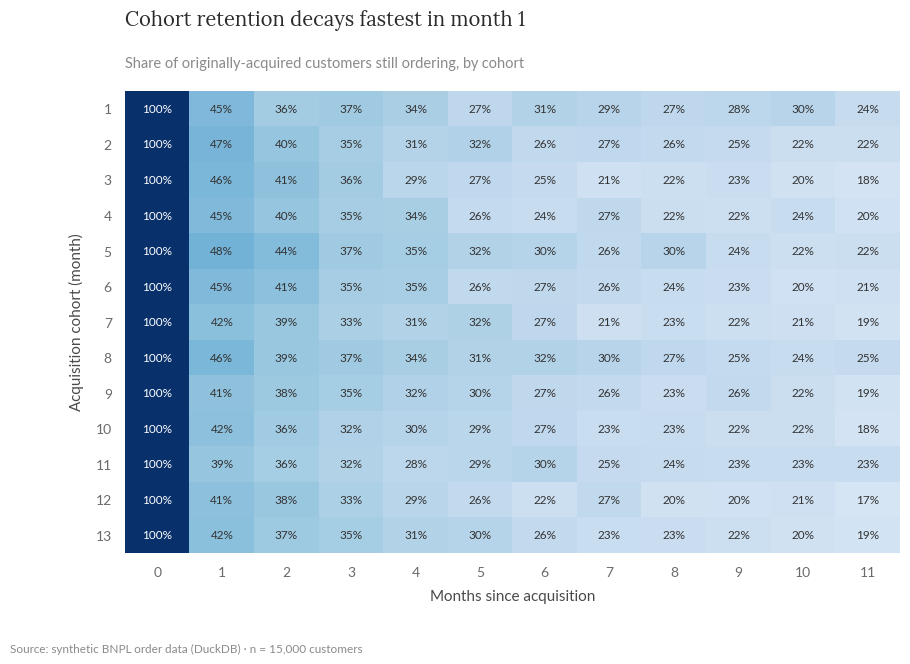

Month-1 retention (avg across full cohorts): 43.8%


In [6]:
cohort = run_sql_file(con, "01_cohort_revenue.sql")
n_customers = len(customers)
SOURCE = f"Source: synthetic BNPL order data (DuckDB) · n = {n_customers:,} customers"

MAX_MONTHS_SINCE = 11
cohort_ages = cohort.groupby("cohort_month")["months_since_acquisition"].max()
full_cohorts = cohort_ages[cohort_ages >= MAX_MONTHS_SINCE].index
mat = cohort[cohort.cohort_month.isin(full_cohorts) & (cohort.months_since_acquisition <= MAX_MONTHS_SINCE)]
pivot = mat.pivot(index="cohort_month", columns="months_since_acquisition", values="retention_rate")

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8.5, color="white" if v > 0.5 else "#333")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
style_ax(ax, title="Cohort retention decays fastest in month 1",
         subtitle="Share of originally-acquired customers still ordering, by cohort",
         xlabel="Months since acquisition", ylabel="Acquisition cohort (month)", grid_axis=None)
add_footnote(fig, SOURCE)
plt.show()

print(f"Month-1 retention (avg across full cohorts): {mat[mat.months_since_acquisition == 1]['retention_rate'].mean():.1%}")

**Figure 1.** Cohort retention rate by months since acquisition.

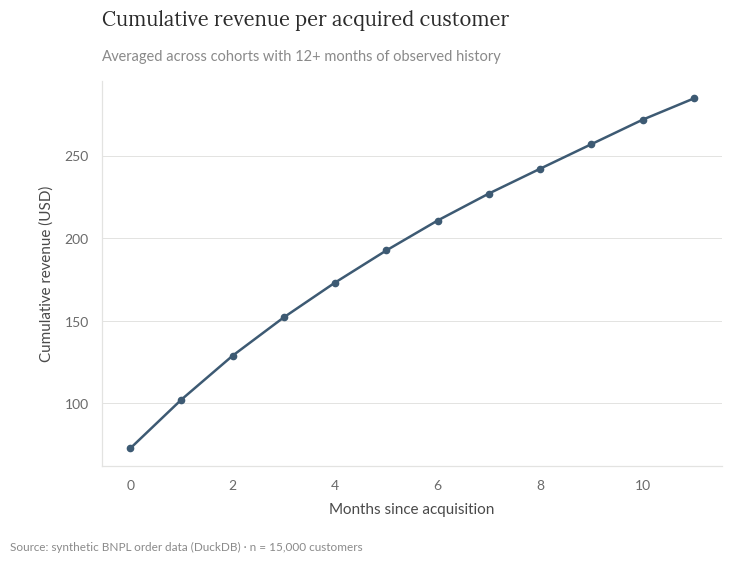

Month-11 cumulative revenue per acquired customer: 284.58 USD


In [7]:
avg_curve = mat.groupby("months_since_acquisition")["revenue_per_acquired_customer"].mean()
cum_curve = avg_curve.cumsum()
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cum_curve.index, cum_curve.values, color=SLATE, linewidth=1.8, marker="o", markersize=4.5)
style_ax(ax, title="Cumulative revenue per acquired customer",
         subtitle=f"Averaged across cohorts with {MAX_MONTHS_SINCE + 1}+ months of observed history",
         xlabel="Months since acquisition", ylabel="Cumulative revenue (USD)")
add_footnote(fig, SOURCE)
plt.show()

print(f"Month-{MAX_MONTHS_SINCE} cumulative revenue per acquired customer: {cum_curve.iloc[-1]:.2f} USD")

**Figure 2.** Cumulative revenue per acquired customer, averaged across mature cohorts.

## 3. GMV contribution (driver) decomposition

GMV is a multiplicative KPI tree: `GMV = active customers x orders per customer x average order value`. A log-share decomposition attributes a change in GMV between two periods to each driver in proportion to its share of the total log-growth, which is the standard way to split a multiplicative change into additive dollar contributions.

`sql/02_monthly_kpis.sql` produces the calendar-month KPI table; the decomposition itself is plain Python/numpy.

In [8]:
print(open("../sql/02_monthly_kpis.sql").read())

-- Calendar-month KPIs, aggregated to the granularity a contribution
-- decomposition needs: GMV = active_customers x orders_per_customer x
-- avg_order_value. The decomposition arithmetic itself happens in Python
-- (src/contribution.py); this query just produces the clean monthly table.
SELECT
    order_month_index AS month_index,
    COUNT(DISTINCT customer_id) AS active_customers,
    COUNT(*) AS orders,
    ROUND(SUM(order_value_usd), 2) AS gmv_usd,
    ROUND(SUM(fee_revenue_usd), 2) AS revenue_usd,
    ROUND(SUM(order_value_usd) / COUNT(*), 2) AS avg_order_value_usd,
    ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT customer_id), 3) AS orders_per_customer
FROM orders
GROUP BY 1
ORDER BY 1;



In [9]:
kpis = run_sql_file(con, "02_monthly_kpis.sql")

def decompose(row_a, row_b):
    log_c = np.log(row_b["active_customers"] / row_a["active_customers"])
    log_f = np.log(row_b["orders_per_customer"] / row_a["orders_per_customer"])
    log_v = np.log(row_b["avg_order_value_usd"] / row_a["avg_order_value_usd"])
    total_log = log_c + log_f + log_v
    delta_gmv = row_b["gmv_usd"] - row_a["gmv_usd"]
    if abs(total_log) < 1e-9:
        shares = {"customers": 1/3, "frequency": 1/3, "avg_order_value": 1/3}
    else:
        shares = {"customers": log_c/total_log, "frequency": log_f/total_log, "avg_order_value": log_v/total_log}
    return {k: v * delta_gmv for k, v in shares.items()}, delta_gmv

kpis.head()

,month_index,active_customers,orders,gmv_usd,revenue_usd,avg_order_value_usd,orders_per_customer
0,1,307,604,358522.17,23304.02,593.58,1.967
1,2,464,847,494633.34,32151.17,583.98,1.825
2,3,621,1208,722193.35,46942.66,597.84,1.945
3,4,806,1476,868216.73,56434.00,588.22,1.831
4,5,949,1726,1024513.29,66593.40,593.58,1.819


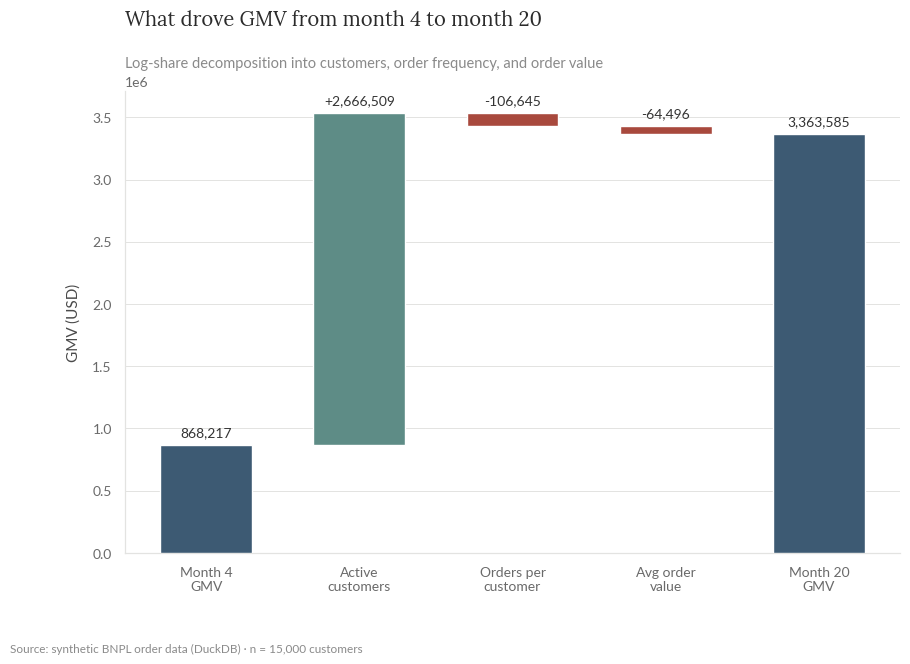

Month 4 GMV: 868,217 -> Month 20 GMV: 3,363,585 (delta 2,495,368)
Contribution breakdown: {'customers': np.float64(2666509.0), 'frequency': np.float64(-106645.0), 'avg_order_value': np.float64(-64496.0)}


In [10]:
row_a = kpis[kpis.month_index == 4].iloc[0]
row_b = kpis[kpis.month_index == 20].iloc[0]
contributions, delta_gmv = decompose(row_a, row_b)

labels = ["Month 4\nGMV", "Active\ncustomers", "Orders per\ncustomer", "Avg order\nvalue", "Month 20\nGMV"]
values = [row_a["gmv_usd"], contributions["customers"], contributions["frequency"], contributions["avg_order_value"], row_b["gmv_usd"]]
cumulative = [values[0]]
for v in values[1:-1]:
    cumulative.append(cumulative[-1] + v)
cumulative.append(values[-1])

fig, ax = plt.subplots(figsize=(10, 6))
bottoms_plot = [0, min(cumulative[0], cumulative[1]), min(cumulative[1], cumulative[2]), min(cumulative[2], cumulative[3]), 0]
heights_plot = [values[0], abs(values[1]), abs(values[2]), abs(values[3]), values[4]]
colors = [SLATE, (MUTED_TEAL if values[1] >= 0 else MUTED_RED), (MUTED_TEAL if values[2] >= 0 else MUTED_RED),
          (MUTED_TEAL if values[3] >= 0 else MUTED_RED), SLATE]
ax.bar(range(5), heights_plot, bottom=bottoms_plot, color=colors, width=0.6, zorder=3)
for i, (v, b) in enumerate(zip(values, bottoms_plot)):
    label_y = b + heights_plot[i] + (max(values[0], values[-1]) * 0.02)
    sign = "+" if (0 < i < 4 and v >= 0) else ("" if i in (0, 4) else "-")
    ax.text(i, label_y, f"{sign}{abs(v):,.0f}", ha="center", fontsize=10, color="#333")
ax.set_xticks(range(5)); ax.set_xticklabels(labels)
style_ax(ax, title="What drove GMV from month 4 to month 20",
         subtitle="Log-share decomposition into customers, order frequency, and order value", ylabel="GMV (USD)")
add_footnote(fig, SOURCE)
plt.show()

print(f"Month 4 GMV: {row_a['gmv_usd']:,.0f} -> Month 20 GMV: {row_b['gmv_usd']:,.0f} (delta {delta_gmv:,.0f})")
print("Contribution breakdown:", {k: round(v, 0) for k, v in contributions.items()})

**Figure 3.** GMV decomposition, month 4 to month 20: active customers, orders per customer, average order value.

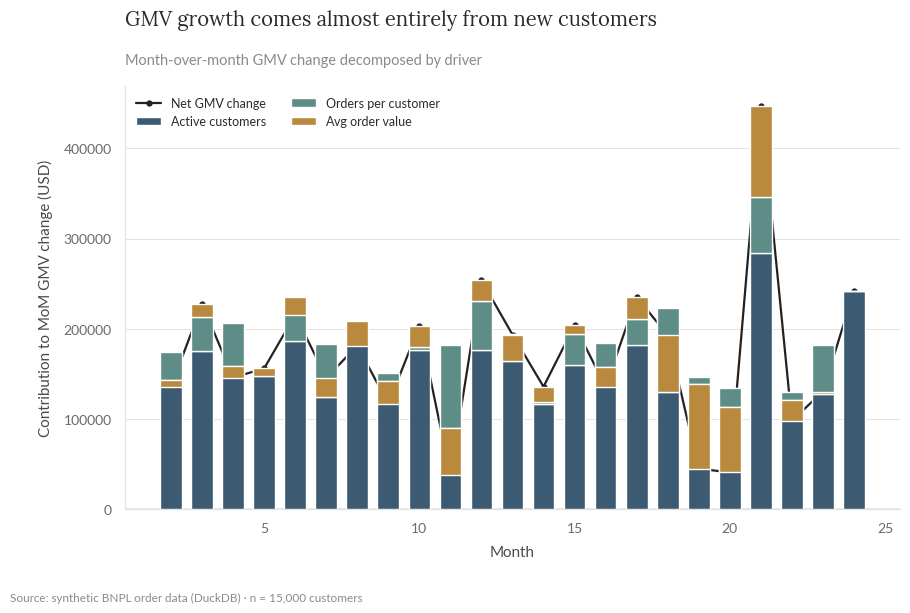

Customers is the largest-magnitude contributor in 100% of months


In [11]:
monthly_contribs = []
for m in range(2, int(kpis.month_index.max()) + 1):
    prev = kpis[kpis.month_index == m - 1]
    curr = kpis[kpis.month_index == m]
    if prev.empty or curr.empty:
        continue
    c, delta = decompose(prev.iloc[0], curr.iloc[0])
    c["month_index"] = m
    c["delta_gmv"] = delta
    monthly_contribs.append(c)
mc = pd.DataFrame(monthly_contribs)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(mc.month_index, mc.customers, color=SLATE, label="Active customers", width=0.7, zorder=3)
ax.bar(mc.month_index, mc.frequency, bottom=mc.customers, color=MUTED_TEAL, label="Orders per customer", width=0.7, zorder=3)
below = mc.customers + mc.frequency
ax.bar(mc.month_index, mc.avg_order_value, bottom=below, color=MUTED_AMBER, label="Avg order value", width=0.7, zorder=3)
ax.plot(mc.month_index, mc.delta_gmv, color="#222222", linewidth=1.6, marker="o", markersize=3.5, label="Net GMV change")
ax.axhline(0, color=GREY, linewidth=1)
style_ax(ax, title="GMV growth comes almost entirely from new customers",
         subtitle="Month-over-month GMV change decomposed by driver",
         xlabel="Month", ylabel="Contribution to MoM GMV change (USD)")
ax.legend(loc="upper left", fontsize=9, ncol=2)
add_footnote(fig, SOURCE)
plt.show()

print("Customers is the largest-magnitude contributor in",
      f"{(mc[['customers','frequency','avg_order_value']].abs().idxmax(axis=1) == 'customers').mean():.0%} of months")

**Figure 4.** Month-over-month GMV change decomposed by driver.

New customer acquisition dominates every month; order frequency and average order value are each net-negative contributors over the period (Figure 3, Figure 4). This is a growth-masks-mix-shift pattern: GMV keeps climbing because the top of the funnel keeps growing, while the underlying customer base is quietly getting less engaged and lower-value per head. That is exactly what channel mix shift would produce, which the next section checks directly.

## 4. Acquisition channel quality and mix shift (SQL)

`sql/03_channel_quality.sql` compares average orders and revenue per customer by channel. `sql/04_channel_mix_shift.sql` uses a window function to compute each channel's share of every acquisition cohort.

In [12]:
print(open("../sql/03_channel_quality.sql").read())
print(open("../sql/04_channel_mix_shift.sql").read())

-- Acquisition channel quality: average orders and revenue per customer by
-- channel, over the customer's full observed lifetime so far.
WITH channel_orders AS (
    SELECT
        c.acquisition_channel,
        o.customer_id,
        COUNT(*) AS n_orders,
        SUM(o.fee_revenue_usd) AS revenue_usd
    FROM orders o
    JOIN customers c ON c.customer_id = o.customer_id
    GROUP BY 1, 2
)
SELECT
    acquisition_channel,
    COUNT(*) AS customers,
    ROUND(AVG(n_orders), 2) AS avg_orders_per_customer,
    ROUND(AVG(revenue_usd), 2) AS avg_revenue_per_customer_usd,
    ROUND(SUM(revenue_usd), 2) AS total_revenue_usd
FROM channel_orders
GROUP BY 1
ORDER BY avg_revenue_per_customer_usd DESC;

-- Channel mix by acquisition cohort, using a window function to get each
-- channel's share of that month's acquisitions. This is what feeds the
-- "growth masking a mix shift toward lower-quality channels" finding.
SELECT
    cohort_month,
    acquisition_channel,
    COUNT(*) AS customers,
   

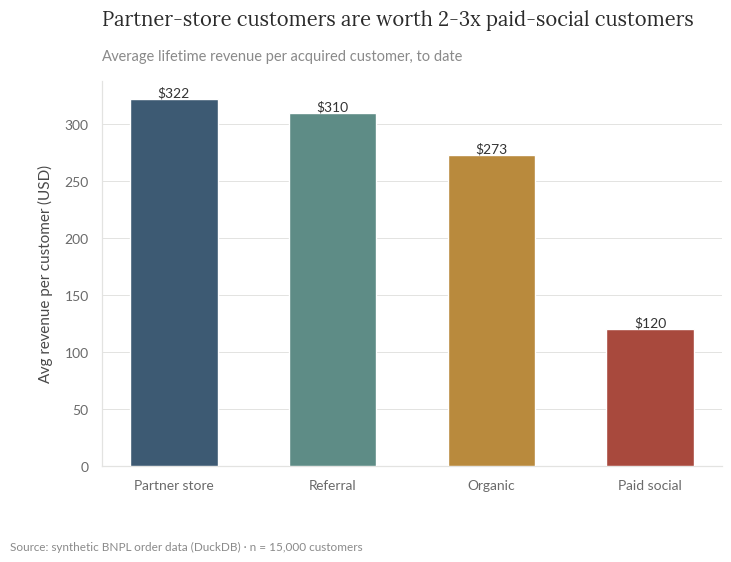

,acquisition_channel,customers,avg_orders_per_customer,avg_revenue_per_customer_usd,total_revenue_usd
0,partner_store,3564,8.51,321.93,1147370.38
1,referral,2079,8.10,310.09,644667.01
2,organic,4256,7.23,272.60,1160200.45
3,paid_social,5101,3.22,120.44,614374.21


In [13]:
CHANNEL_LABELS = {"partner_store": "Partner store", "referral": "Referral", "organic": "Organic", "paid_social": "Paid social"}
CHANNEL_ORDER = ["partner_store", "referral", "organic", "paid_social"]

quality = run_sql_file(con, "03_channel_quality.sql")
q = quality.set_index("acquisition_channel").reindex(quality.sort_values("avg_revenue_per_customer_usd", ascending=False)["acquisition_channel"])

fig, ax = plt.subplots(figsize=(8, 5))
labels = [CHANNEL_LABELS[c] for c in q.index]
ax.bar(labels, q["avg_revenue_per_customer_usd"], color=PALETTE[:len(q)], width=0.55, zorder=3)
for i, v in enumerate(q["avg_revenue_per_customer_usd"]):
    ax.text(i, v + 2, f"${v:,.0f}", ha="center", fontsize=10, color="#333")
style_ax(ax, title="Partner-store customers are worth 2-3x paid-social customers",
         subtitle="Average lifetime revenue per acquired customer, to date", ylabel="Avg revenue per customer (USD)")
add_footnote(fig, SOURCE)
plt.show()
quality

**Figure 5.** Average lifetime revenue per acquired customer, by acquisition channel.

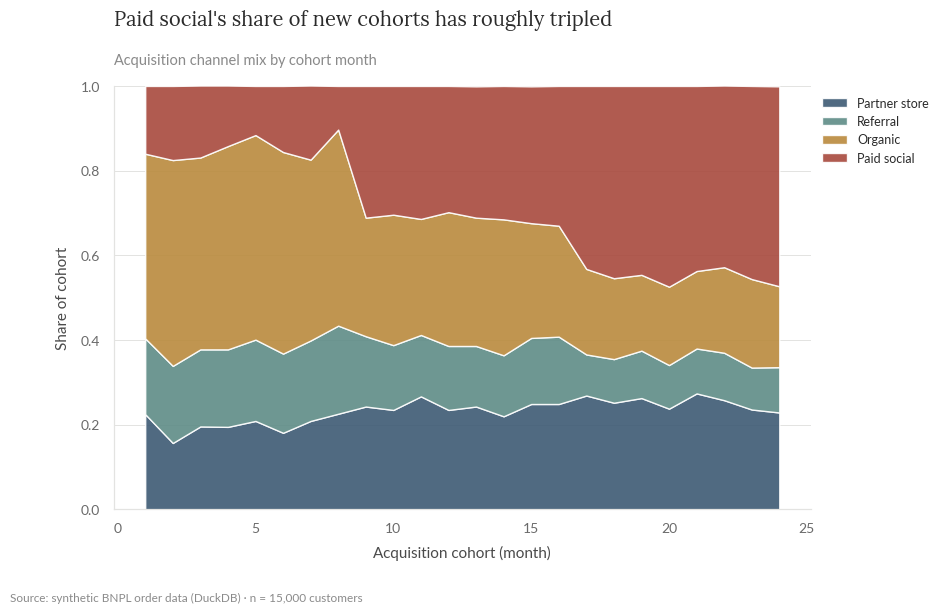

In [14]:
mix = run_sql_file(con, "04_channel_mix_shift.sql")
pivot = mix.pivot(index="cohort_month", columns="acquisition_channel", values="channel_share").fillna(0)
pivot = pivot[[c for c in CHANNEL_ORDER if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.stackplot(pivot.index, [pivot[c] for c in pivot.columns], labels=[CHANNEL_LABELS[c] for c in pivot.columns],
             colors=PALETTE[:len(pivot.columns)], alpha=0.9)
style_ax(ax, title="Paid social's share of new cohorts has roughly tripled",
         subtitle="Acquisition channel mix by cohort month", xlabel="Acquisition cohort (month)", ylabel="Share of cohort")
ax.set_ylim(0, 1)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=9)
add_footnote(fig, SOURCE)
plt.show()

**Figure 6.** Acquisition channel mix by cohort month.

This confirms the mechanism behind the contribution decomposition: paid social, the lowest-quality and lowest-frequency channel (Figure 5), has grown from roughly a sixth to nearly half of every new cohort (Figure 6). Growth is increasingly funded by a channel that produces customers worth about a third as much as the best channel.

## 4b. Growth trend and revenue concentration (SQL)

The decomposition in section 3 explains what drove GMV between two snapshots (month 4 vs. month 20). Two more questions need the full monthly series rather than just those two points: is the growth *rate* itself holding up, and how much of a given cohort's revenue rides on a handful of its biggest spenders.

`sql/05_kpi_trend_with_deltas.sql` uses `LAG()` to pull each month's prior-month GMV and compute month-over-month growth, then a moving-average window frame (`AVG() OVER (... ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)`) to smooth that noisy month-to-month number into a trend line.

In [15]:
print(open("../sql/05_kpi_trend_with_deltas.sql").read())

-- Monthly GMV with month-over-month growth and a trailing 3-month
-- moving average, computed with LAG() and a moving window frame. The
-- moving average exists because MoM growth is noisy month to month;
-- smoothing it out is what actually shows whether growth is
-- decelerating, rather than only whether GMV is still rising.
WITH monthly AS (
    SELECT
        order_month_index AS month_index,
        SUM(order_value_usd) AS gmv_usd
    FROM orders
    GROUP BY 1
)
SELECT
    month_index,
    ROUND(gmv_usd, 2) AS gmv_usd,
    ROUND(LAG(gmv_usd) OVER (ORDER BY month_index), 2) AS prior_month_gmv_usd,
    ROUND(
        (gmv_usd - LAG(gmv_usd) OVER (ORDER BY month_index))
        / NULLIF(LAG(gmv_usd) OVER (ORDER BY month_index), 0) * 100, 2
    ) AS mom_growth_pct,
    ROUND(
        AVG(gmv_usd) OVER (ORDER BY month_index ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2
    ) AS gmv_3mo_moving_avg
FROM monthly
ORDER BY month_index;



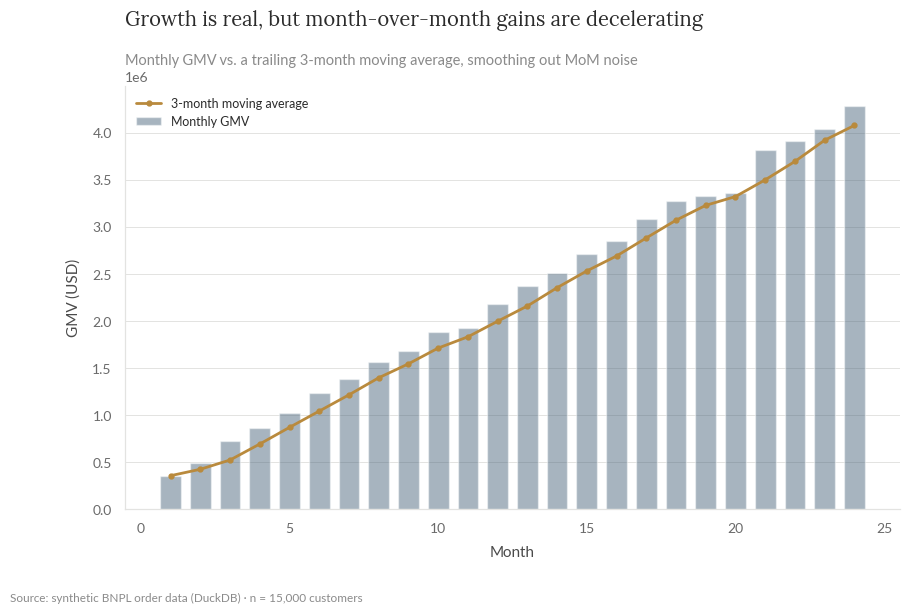

Avg MoM growth, months 2-6: 28.6% -> months 20-24: 5.3%


In [16]:
trend = run_sql_file(con, "05_kpi_trend_with_deltas.sql")
SOURCE = f"Source: synthetic BNPL order data (DuckDB) · n = {n_customers:,} customers"

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(trend.month_index, trend.gmv_usd, color=SLATE, alpha=0.45, width=0.7, zorder=2, label="Monthly GMV")
ax.plot(trend.month_index, trend.gmv_3mo_moving_avg, color=MUTED_AMBER, linewidth=2,
        marker="o", markersize=3.5, zorder=3, label="3-month moving average")
style_ax(ax, title="Growth is real, but month-over-month gains are decelerating",
         subtitle="Monthly GMV vs. a trailing 3-month moving average, smoothing out MoM noise",
         xlabel="Month", ylabel="GMV (USD)")
ax.legend(loc="upper left", fontsize=9)
add_footnote(fig, SOURCE)
plt.show()

early = trend[trend.month_index.between(2, 6)]["mom_growth_pct"].mean()
late = trend[trend.month_index.between(20, 24)]["mom_growth_pct"].mean()
print(f"Avg MoM growth, months 2-6: {early:.1f}% -> months 20-24: {late:.1f}%")

**Figure 7.** Monthly GMV vs. a trailing 3-month moving average.

GMV is still growing every month, but the pace is not: average month-over-month growth runs 28.6% across months 2-6 and has fallen to 5.3% across months 20-24 (Figure 7). That's a materially different growth story than "GMV tripled," even though both statements are true at once.

`sql/06_top_customers_by_cohort.sql` uses `DENSE_RANK()` partitioned by acquisition cohort to rank customers by revenue within their own cohort, then flags each cohort's top 5%. That's normalized to a percentage rather than a fixed headcount deliberately: cohorts here range from roughly 300 to 950 customers, so a fixed count of 5 would look artificially more "concentrated" in a small cohort than a large one purely from cohort size, not from any real difference in concentration.

In [17]:
print(open("../sql/06_top_customers_by_cohort.sql").read())

-- Within each acquisition cohort, rank customers by total revenue and
-- flag the top 5% (not a fixed headcount, cohorts range from ~300 to
-- ~950 customers, so a fixed count of 5 would mechanically look more
-- "concentrated" for small cohorts and less for large ones regardless
-- of actual concentration). DENSE_RANK partitioned by cohort_month,
-- normalized against each cohort's own size.
WITH customer_revenue AS (
    SELECT
        c.cohort_month,
        c.customer_id,
        SUM(o.fee_revenue_usd) AS revenue_usd
    FROM customers c
    JOIN orders o ON o.customer_id = c.customer_id
    GROUP BY 1, 2
),
ranked AS (
    SELECT
        cohort_month,
        customer_id,
        revenue_usd,
        DENSE_RANK() OVER (PARTITION BY cohort_month ORDER BY revenue_usd DESC) AS revenue_rank,
        COUNT(*) OVER (PARTITION BY cohort_month) AS cohort_size
    FROM customer_revenue
)
SELECT
    cohort_month,
    MAX(cohort_size) AS cohort_size,
    ROUND(SUM(CASE WHEN revenue_rank <= 

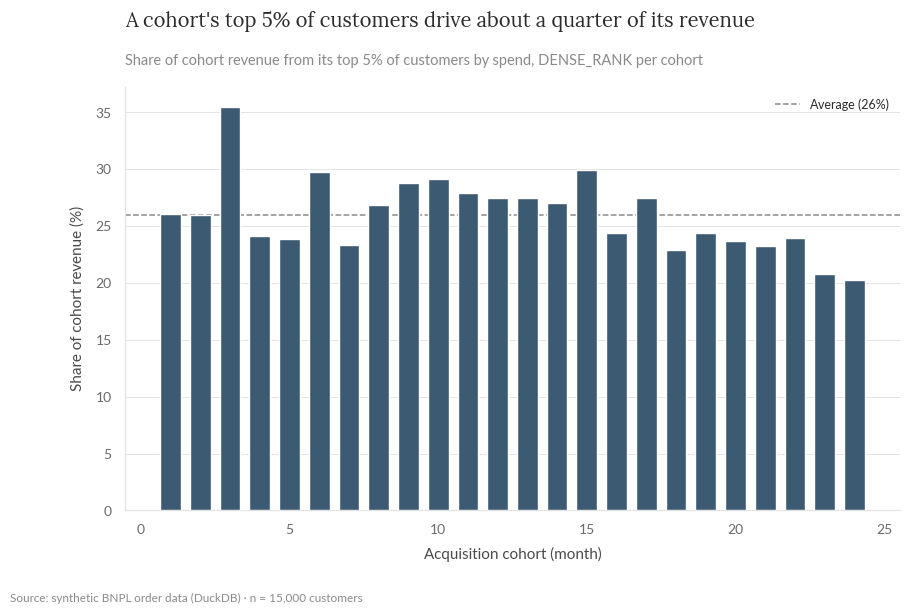

Average top-5% revenue share across cohorts: 26.0%
Range: 20.3% to 35.5%


In [18]:
conc = run_sql_file(con, "06_top_customers_by_cohort.sql")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(conc.cohort_month, conc.top5pct_revenue_share * 100, color=SLATE, width=0.7, zorder=3)
mean_share = conc.top5pct_revenue_share.mean() * 100
ax.axhline(mean_share, color=GREY, linestyle="--", linewidth=1.1, label=f"Average ({mean_share:.0f}%)")
style_ax(ax, title="A cohort's top 5% of customers drive about a quarter of its revenue",
         subtitle="Share of cohort revenue from its top 5% of customers by spend, DENSE_RANK per cohort",
         xlabel="Acquisition cohort (month)", ylabel="Share of cohort revenue (%)")
ax.legend(loc="upper right", fontsize=9)
add_footnote(fig, SOURCE)
plt.show()

print(f"Average top-5% revenue share across cohorts: {mean_share:.1f}%")
print(f"Range: {conc.top5pct_revenue_share.min()*100:.1f}% to {conc.top5pct_revenue_share.max()*100:.1f}%")

**Figure 8.** Share of cohort revenue from its top 5% of customers by spend, by acquisition cohort.

Across all 24 cohorts, the top 5% of customers consistently account for about a quarter of the cohort's total revenue (26.0% on average, ranging from 20.3% to 35.5%), a fairly stable Pareto-style pattern rather than something that drifts as the platform scales. That's worth a VIP retention program on its own merits, but it's not a growing risk: concentration isn't creeping up as cohorts get larger (Figure 8).

## 5. Probabilistic customer lifetime value (BG/NBD + Gamma-Gamma)

The standard non-contractual CLV approach. BG/NBD models each customer's purchase frequency and the probability they've churned, using only recency, frequency, and tenure (`T`). Gamma-Gamma models average order value conditional on frequency, assuming value and frequency are roughly independent (checked below). Combined, they give a forward-looking expected value per customer using only transaction history, no features required (Figure 9).

In [19]:
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data

OBS_END = pd.Timestamp("2026-01-01")
summary = summary_data_from_transaction_data(orders, "customer_id", "order_date",
                                              monetary_value_col="order_value_usd",
                                              observation_period_end=OBS_END, freq="D")
print(f"Repeat purchasers: {(summary['frequency'] > 0).mean():.1%} of customers")
summary.head()

Repeat purchasers: 82.7% of customers


,frequency,recency,T,monetary_value
customer_id,,,,
1,1.0,107.0,196.0,323.950000
2,0.0,0.0,56.0,0.000000
3,3.0,84.0,112.0,701.950000
4,7.0,270.0,448.0,332.607143
5,1.0,47.0,392.0,466.660000


In [20]:
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary["frequency"], summary["recency"], summary["T"])

repeat = summary[summary["frequency"] > 0].copy()
print(f"Gamma-Gamma independence check (should be near 0): "
      f"{repeat[['frequency', 'monetary_value']].corr().iloc[0, 1]:.3f}")

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(repeat["frequency"], repeat["monetary_value"])
print(bgf)
print(ggf)

Gamma-Gamma independence check (should be near 0): 0.021


<lifetimes.BetaGeoFitter: fitted with 15000 subjects, a: 0.50, alpha: 27.16, b: 2.78, r: 0.92>
<lifetimes.GammaGammaFitter: fitted with 12411 subjects, p: 13.28, q: 0.76, v: 13.11>


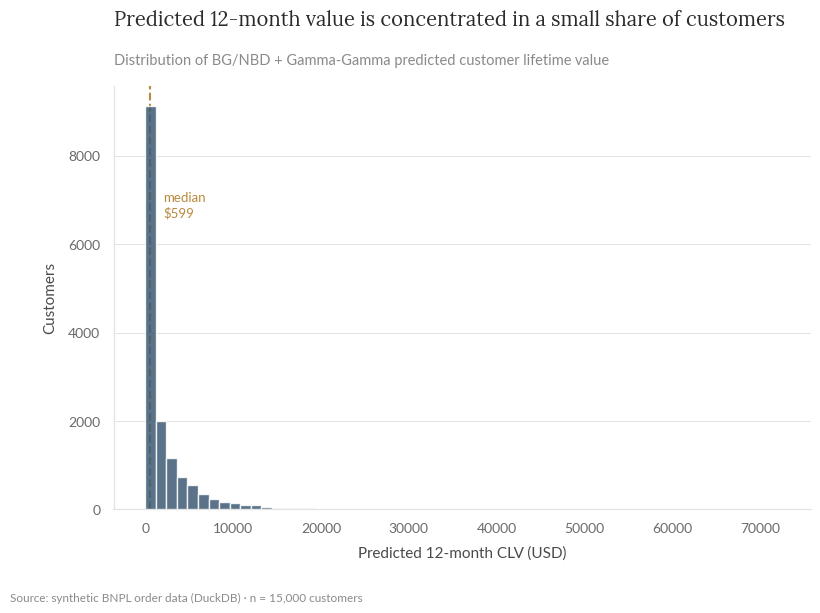

Median predicted 12-month CLV: 599 USD
Top decile of customers captures 52.7% of predicted 12-month value


In [21]:
clv = ggf.customer_lifetime_value(
    bgf, summary["frequency"], summary["recency"], summary["T"],
    repeat["monetary_value"].reindex(summary.index, fill_value=summary["monetary_value"].mean()),
    time=12, freq="D", discount_rate=0.01,
).rename("predicted_clv_12m_usd")
result = summary.join(clv)

fig, ax = plt.subplots(figsize=(9, 5.5))
vals = result["predicted_clv_12m_usd"].clip(lower=0)
ax.hist(vals, bins=60, color=SLATE, alpha=0.85, zorder=3)
median = vals.median()
ax.axvline(median, color=MUTED_AMBER, linewidth=1.5, linestyle="--")
ax.text(median + vals.max() * 0.02, ax.get_ylim()[1] * 0.75, f"median\n${median:,.0f}", fontsize=9.5, color=MUTED_AMBER, va="top")
style_ax(ax, title="Predicted 12-month value is concentrated in a small share of customers",
         subtitle="Distribution of BG/NBD + Gamma-Gamma predicted customer lifetime value",
         xlabel="Predicted 12-month CLV (USD)", ylabel="Customers")
add_footnote(fig, SOURCE)
plt.show()

top_decile_share = vals.sort_values(ascending=False).head(int(len(vals) * 0.1)).sum() / vals.sum()
print(f"Median predicted 12-month CLV: {median:,.0f} USD")
print(f"Top decile of customers captures {top_decile_share:.1%} of predicted 12-month value")

**Figure 9.** Distribution of predicted 12-month customer lifetime value (BG/NBD + Gamma-Gamma).

### Validation: calibration/holdout split

Fitting and predicting on the same data a model was trained on tells you nothing about forward-looking accuracy. The standard `lifetimes` validation approach holds out the last 6 months: fit BG/NBD on each customer's calibration-period frequency/recency/tenure, then check whether the model's predicted holdout purchase count tracks what actually happened (Figure 10).

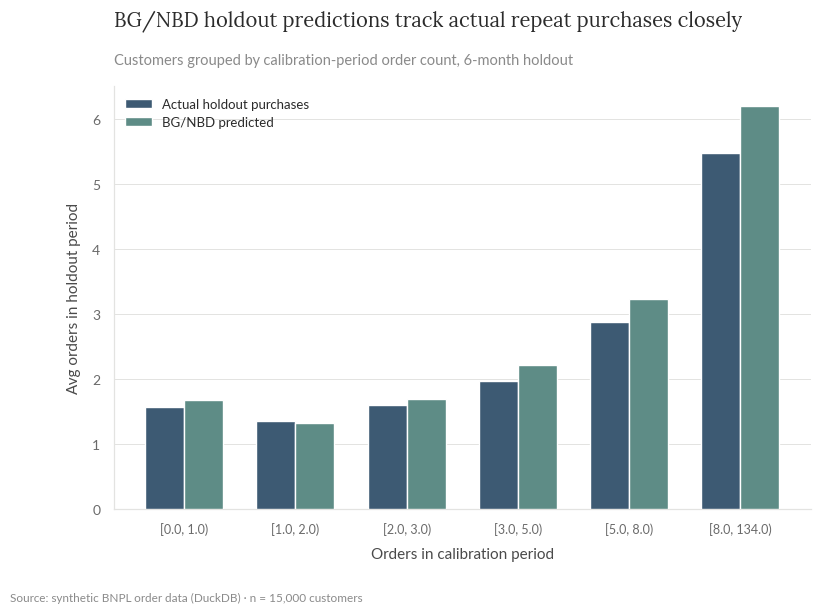

Calibration/holdout MAE (orders): 1.865


,freq_bucket,actual,predicted,n
0,"[0.0, 1.0)",1.577643,1.688546,2138
1,"[1.0, 2.0)",1.354906,1.326912,1916
2,"[2.0, 3.0)",1.606312,1.696657,1204
3,"[3.0, 5.0)",1.965132,2.215591,1520
4,"[5.0, 8.0)",2.885206,3.230638,1237
5,"[8.0, 134.0)",5.477764,6.194201,1664


In [22]:
calib_end = OBS_END - pd.DateOffset(months=6)
cal_hold = calibration_and_holdout_data(orders, "customer_id", "order_date",
                                         calibration_period_end=calib_end, observation_period_end=OBS_END, freq="D")

bgf_cal = BetaGeoFitter(penalizer_coef=0.001)
bgf_cal.fit(cal_hold["frequency_cal"], cal_hold["recency_cal"], cal_hold["T_cal"])

holdout_days = (OBS_END - calib_end).days
cal_hold["predicted_holdout"] = bgf_cal.conditional_expected_number_of_purchases_up_to_time(
    holdout_days, cal_hold["frequency_cal"], cal_hold["recency_cal"], cal_hold["T_cal"])

bucket_edges = [0, 1, 2, 3, 5, 8, cal_hold["frequency_cal"].max() + 1]
cal_hold["freq_bucket"] = pd.cut(cal_hold["frequency_cal"], bins=bucket_edges, right=False)
agg = cal_hold.groupby("freq_bucket", observed=True).agg(
    actual=("frequency_holdout", "mean"), predicted=("predicted_holdout", "mean"), n=("frequency_holdout", "size")).reset_index()

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(agg)); width = 0.35
ax.bar(x - width/2, agg["actual"], width, color=SLATE, label="Actual holdout purchases", zorder=3)
ax.bar(x + width/2, agg["predicted"], width, color=MUTED_TEAL, label="BG/NBD predicted", zorder=3)
ax.set_xticks(x); ax.set_xticklabels([str(b) for b in agg["freq_bucket"]], fontsize=9)
style_ax(ax, title="BG/NBD holdout predictions track actual repeat purchases closely",
         subtitle="Customers grouped by calibration-period order count, 6-month holdout",
         xlabel="Orders in calibration period", ylabel="Avg orders in holdout period")
ax.legend(loc="upper left", fontsize=9.5)
add_footnote(fig, SOURCE)
plt.show()

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(cal_hold["frequency_holdout"], cal_hold["predicted_holdout"])
print(f"Calibration/holdout MAE (orders): {mae:.3f}")
agg

**Figure 10.** BG/NBD holdout predictions vs. actual repeat purchases, by calibration-period order count.

## 6. Early-life predictive model (day-30 features -> 12-month GMV)

BG/NBD needs several months of transaction history to produce a stable estimate. In production, the more useful model scores a customer right after signup. This section trains a gradient boosting regressor on only the first 30 days of behavior plus acquisition attributes, predicting total GMV over the following 12 months, for cohorts with a full 12 months of observed history. The target is GMV (order_value_usd), not the company's fee revenue (metrics.REVENUE) - the two are proportional here since the take rate is constant, but the label says GMV so the two governed metrics don't get conflated.

In [23]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

HORIZON_MONTHS = 12
eligible = customers[customers["cohort_month"] <= 24 - HORIZON_MONTHS].copy()
merged = orders.merge(customers[["customer_id", "cohort_month"]], on="customer_id")
merged["days_since_acq"] = merged["months_since_acquisition"] * 28

day30 = merged[merged["days_since_acq"] <= 30]
feats = day30.groupby("customer_id").agg(orders_first_30d=("order_id", "count"),
                                          gmv_first_30d=("order_value_usd", "sum")).reindex(eligible["customer_id"]).fillna(0)
second_order_day = (day30[day30["months_since_acquisition"] > 0].groupby("customer_id")["days_since_acq"].min()
                     .reindex(eligible["customer_id"]))
feats["days_to_second_order"] = second_order_day.fillna(999)
feats["reordered_in_30d"] = second_order_day.notna().astype(int)

horizon = merged[merged["months_since_acquisition"] < HORIZON_MONTHS]
target = horizon.groupby("customer_id")["order_value_usd"].sum().reindex(eligible["customer_id"]).fillna(0)

df_el = eligible.set_index("customer_id").join(feats).join(target.rename("gmv_12m")).reset_index()
df_el.head()

,customer_id,cohort_month,acquisition_channel,city,city_tier,employment_type,mean_order_value_usd,orders_first_30d,gmv_first_30d,days_to_second_order,reordered_in_30d,gmv_12m
0,4,9,organic,Tier 3 metro,tier3,salaried,313.29,2,593.34,28.0,1,2671.80
1,5,11,referral,Tier 2 metro,tier2,informal,290.83,2,700.95,28.0,1,700.95
2,7,1,organic,Tier 1 metro,tier1,salaried,455.76,3,1750.65,28.0,1,4898.83
3,11,11,referral,Tier 2 metro,tier2,informal,531.01,1,569.39,999.0,0,4771.59
4,12,10,paid_social,Tier 3 metro,tier3,self_employed,276.36,2,822.66,28.0,1,1767.04


In [24]:
cat_cols = ["acquisition_channel", "city_tier", "employment_type"]
num_cols = ["orders_first_30d", "gmv_first_30d", "days_to_second_order", "reordered_in_30d"]
X = pd.get_dummies(df_el[cat_cols + num_cols], columns=cat_cols, drop_first=True)
y = df_el["gmv_12m"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)
model = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=7)
model.fit(X_train, y_train)
pred = model.predict(X_test)
r2 = r2_score(y_test, pred)
print(f"Holdout R2: {r2:.3f}  |  n={len(X_test):,}")

Holdout R2: 0.375  |  n=1,385


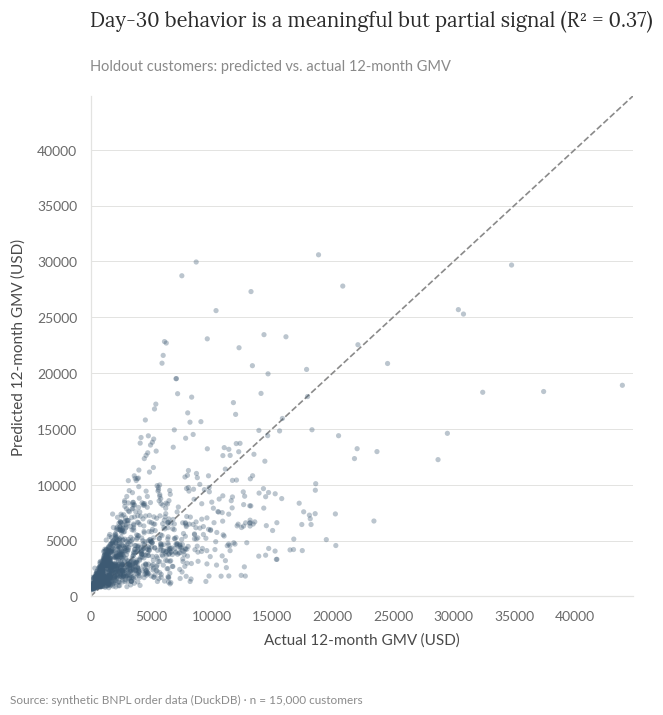

In [25]:
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(y_test, pred, s=14, color=SLATE, alpha=0.35, edgecolor="none", zorder=3)
lims = [0, max(y_test.max(), pred.max()) * 1.02]
ax.plot(lims, lims, color=GREY, linewidth=1.2, linestyle="--")
ax.set_xlim(lims); ax.set_ylim(lims)
style_ax(ax, title=f"Day-30 behavior is a meaningful but partial signal (R² = {r2:.2f})",
         subtitle="Holdout customers: predicted vs. actual 12-month GMV",
         xlabel="Actual 12-month GMV (USD)", ylabel="Predicted 12-month GMV (USD)")
add_footnote(fig, SOURCE)
plt.show()

**Figure 11.** Early-life model: predicted vs. actual 12-month GMV, holdout customers.

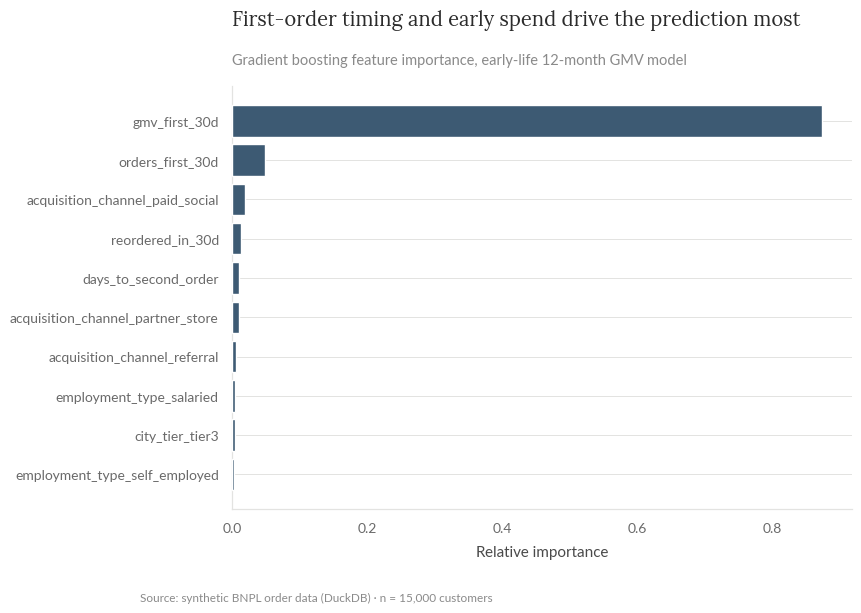

In [26]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(importances.index, importances.values, color=SLATE, zorder=3)
style_ax(ax, title="First-order timing and early spend drive the prediction most",
         subtitle="Gradient boosting feature importance, early-life 12-month GMV model", xlabel="Relative importance")
add_footnote(fig, SOURCE)
plt.show()

**Figure 12.** Gradient boosting feature importance, early-life 12-month GMV model.

Spend and order count in the first 30 days dominate the prediction, well ahead of acquisition channel or demographics (Figure 12). The R² of roughly 0.37 means day-30 behavior is informative but far from the whole story (Figure 11): some customers front-load a purchase and then churn, which the model can't distinguish from a customer who is just getting started. In practice this model would be used to route customers into engagement tiers, not to make a final, one-shot lifetime value call at day 30.

## 7. Limitations

- Synthetic data generated to be BG/NBD + Gamma-Gamma consistent by construction, which favors those models. Real transaction data usually has more structural breaks (promotions, seasonality, product changes) that violate the stationarity assumption.
- The Gamma-Gamma independence check above is a simple correlation; a fuller diagnostic would test independence conditional on tenure as well.
- The early-life model's R² (~0.37) is a realistic, not an inflated, number for a genuinely hard problem. It should be read as a prioritization signal, not a precise dollar forecast per customer.
- Discount rate and 12-month time horizon in the CLV calculation are illustrative choices, not fitted from a real cost-of-capital figure.